# House Price Prediction Solution

This notebook solves the uploaded **HousingNew.csv** dataset as a **supervised machine learning regression problem**.

## Problem Statement
Given structural, locational, and amenity-based features of a residential property, can we build a machine learning model that accurately predicts its market price, and how do we know when the model is good enough to trust?

## Why this is a regression problem
The target variable is **`price`**, which is a continuous numerical value.  
So the task is **regression**, not classification.


In [ ]:
#Name: Tambong Fidelis Junior
#Matricule: LMUI250962
#Department: SWE
#Level: 400(Top-up)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots appear inside the notebook
%matplotlib inline

## 1. Load the dataset

In [5]:
df = pd.read_csv('HousingNew.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Check the shape and structure of the dataset

In [6]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (545, 13)

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## 3. Check for missing values

In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 4. Separate features and target

- **Features (X):** all columns except `price`
- **Target (y):** `price`


In [10]:
X = df.drop('price', axis=1)
y = df['price']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (545, 12)
Target shape: (545,)


## 5. Identify numeric and categorical columns

In [11]:
numeric_features = X.select_dtypes(exclude='object').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## 6. Quick data exploration

In [12]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


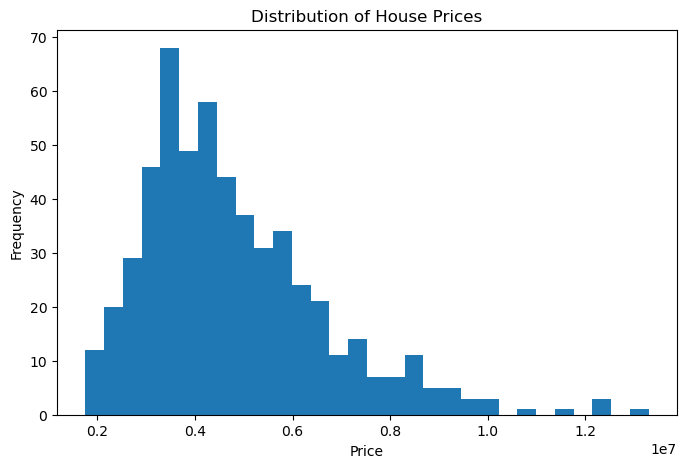

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.show()

## 7. The Processes to build the preprocessing pipeline

- The missing numeric values with the median are filled
- The numeric features are standardized
- The missing categorical values with the most frequent value are filled
- The categorical data is converted into numbers using one-hot encoding


In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Build the regression model

We will use **Linear Regression** as the baseline model because it is simple
  easy to explain, suitable for regression, and a good starting point for model comparison


In [15]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 9. Split the dataset into training and testing sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 12)
X_test : (109, 12)
y_train: (436,)
y_test : (109,)


## 10. Train the model

In [17]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 11. Make predictions

In [18]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


## 12. Evaluating the model

We will use the following
- **MAE (Mean Absolute Error)** → average prediction error
- **RMSE (Root Mean Squared Error)** → gives more penalty to large errors
- **R² Score** → shows how much of the variation in price is explained by the model


In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 970043.4
RMSE: 1324506.96
R²  : 0.6529


## 13. Cross-validation

Cross-validation helps us check whether the model is stable and not just lucky on one train-test split.


In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(model, X, y, cv=cv, scoring='r2')
cv_mae = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
cv_rmse = (-cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')) ** 0.5

print("R² scores for 5 folds:", np.round(cv_r2, 4))
print("Average CV R²  :", round(cv_r2.mean(), 4))
print("Average CV MAE :", round(cv_mae.mean(), 2))
print("Average CV RMSE:", round(cv_rmse.mean(), 2))

R² scores for 5 folds: [0.6529 0.7121 0.4928 0.658  0.6464]
Average CV R²  : 0.6324
Average CV MAE : 807179.92
Average CV RMSE: 1084537.9


## 14. Visualize actual vs predicted prices

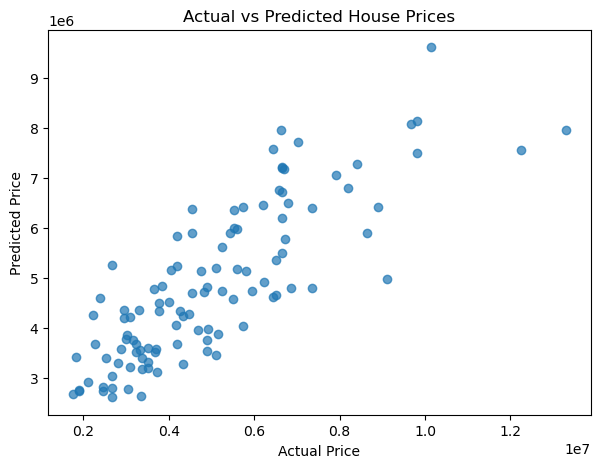

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

## 15. Interpretation of results

For this dataset, the baseline Linear Regression model gives a **moderate** performance.

### Meaning of the results
- If **R² is around 0.63 to 0.65**, the model explains about **63% to 65%** of the variation in house prices.
- This means the model is **useful as a support tool** for estimating prices.
- However, it is **not perfect** and should not fully replace human judgment.

### Reason why this model should  be trusted.
Yes, but as a **decision-support system**, not as the only final authority.

The model is useful when:
- agents want a quick data-driven estimate
- the agency wants consistent pricing
- management wants a more defensible pricing process

The model should still be combined with:
- agent experience
- neighborhood trends
- current market conditions
- special property characteristics not captured in the dataset


## 16. Final conclusion

A machine learning regression model can be built to predict house prices from structural, locational, and amenity-based features. Using the uploaded housing dataset, Linear Regression provides a reasonable baseline and shows that price prediction is possible with moderate accuracy.

This means the system can help a real estate agency:
- reduce overpricing
- reduce underpricing
- improve consistency
- make pricing decisions more evidence-based

Conclusion: The model is good enough to **assist** pricing decisions, but not strong enough to completely replace expert judgment.
